# <div style="color:white;display:inline-block;border-radius:4px;background-color:#a731b0 ;font-family:Nexa;overflow:hidden"><p style="padding:8px;color:white;overflow:hidden;font-size:85%;letter-spacing:0.5px;margin:0;border: 6px groove #f0bf19;"><b>1. </b>Data Loading & Strategic Merging</p></div>

- Loading four distinct datasets and merging them on a synchronized Timestamp key.
- Attack data is fragmented. To find patterns, we must align temporal data from different sensors (honeypots) and network layers (ports).
- Using pd.to_datetime with utc=True to normalize various ISO formats and performing an outer join to preserve all attack windows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings('ignore')

plt.style.use('default')   # or 'seaborn-v0_8-whitegrid'

BG_COLOR = "#F8F9FA"      # Light Gray
AX_COLOR = "#FFFFFF"      # White

COLORS = ["#3FB950", "#58A6FF", "#FF7B72", "#D2A8FF", "#FFA657"]
#BG_COLOR = "#2B2B2B"


def load_and_merge():
    # Paths provided by user
    paths = {
        'hp': '/kaggle/input/datasets/jocelyndumlao/attacks-on-honeypots/Attacks on Honeypots (June 2025 - January 2026)/merged_honeypots_new.csv',
        'ports': '/kaggle/input/datasets/jocelyndumlao/attacks-on-honeypots/Attacks on Honeypots (June 2025 - January 2026)/merged_ports_new.csv',
        'total': '/kaggle/input/datasets/jocelyndumlao/attacks-on-honeypots/Attacks on Honeypots (June 2025 - January 2026)/out_all_unique_and_attacks_all_new.csv'
    }
    
    # Load and Normalize Timestamps
    df_hp = pd.read_csv(paths['hp'])
    df_ports = pd.read_csv(paths['ports'])
    df_total = pd.read_csv(paths['total'])
    
    for df in [df_hp, df_ports, df_total]:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
    
    # Merging Strategy
    df = pd.merge(df_hp, df_ports, on='Timestamp', how='outer')
    df = pd.merge(df, df_total, on='Timestamp', how='outer')
    
    return df

df_raw = load_and_merge()
print(f"Dataset Loaded. Shape: {df_raw.shape}")

2026-06-28 01:05:05.091413: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782608705.308265      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782608705.365875      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782608705.866338      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782608705.866371      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782608705.866373      16 computation_placer.cc:177] computation placer alr

Dataset Loaded. Shape: (8544, 14)


In [2]:
# Load the dataset
df =  pd.read_csv('/kaggle/input/datasets/jocelyndumlao/attacks-on-honeypots/Attacks on Honeypots (June 2025 - January 2026)/merged_honeypots_new.csv')
df.head().style.background_gradient(cmap='gist_rainbow')

,Timestamp,Attack_counts_Cowrie,Attack_counts_Dionaea,Attack_counts_Heralding,Attack_counts_Honeytrap,Attack_counts_Tanner,Attack_counts_Mailoney
0,2025-07-07 00:00:00+00:00,7645,nan,12.000000,1,1,81
1,2025-07-07 00:30:00+00:00,7539,nan,0.000000,8,2,70
2,2025-07-07 01:00:00+00:00,7489,nan,0.000000,1,3,68
3,2025-07-07 01:30:00+00:00,7370,nan,0.000000,1,0,64
4,2025-07-07 02:00:00+00:00,7500,nan,0.000000,2,1,72


In [3]:
df =  pd.read_csv('/kaggle/input/datasets/jocelyndumlao/attacks-on-honeypots/Attacks on Honeypots (June 2025 - January 2026)/merged_ports_new.csv')
df.head().style.background_gradient(cmap='turbo')

,Timestamp,Attack_counts_22,Attack_counts_23,Attack_counts_445,Attack_counts_1433,Attack_counts_5900
0,2025-07-07 00:00:00+00:00,1520,6,nan,nan,12.000000
1,2025-07-07 00:30:00+00:00,1492,8,nan,nan,0.000000
2,2025-07-07 01:00:00+00:00,1477,47,nan,nan,0.000000
3,2025-07-07 01:30:00+00:00,1466,9,nan,nan,0.000000
4,2025-07-07 02:00:00+00:00,1485,25,nan,nan,0.000000


In [4]:
df =  pd.read_csv('/kaggle/input/datasets/jocelyndumlao/attacks-on-honeypots/Attacks on Honeypots (June 2025 - January 2026)/out_all_unique_and_attacks_all_new.csv')
df.head().style.background_gradient(cmap='RdYlGn_r')

,Timestamp,Attack_counts,Unique_ips
0,2025-07-07T02:00:00.000+02:00,7744,24
1,2025-07-07T02:30:00.000+02:00,7621,28
2,2025-07-07T03:00:00.000+02:00,7561,28
3,2025-07-07T03:30:00.000+02:00,7435,19
4,2025-07-07T04:00:00.000+02:00,7588,29


In [5]:
df =  pd.read_csv('/kaggle/input/datasets/jocelyndumlao/attacks-on-honeypots/Attacks on Honeypots (June 2025 - January 2026)/source_countries_new.csv')
df.head().style.background_gradient(cmap='YlOrRd')

,Country,Timestamp,Attacks
0,United States,2025-07-07T02:00:00.000+02:00,86
1,United States,2025-07-07T02:30:00.000+02:00,93
2,United States,2025-07-07T03:00:00.000+02:00,86
3,United States,2025-07-07T03:30:00.000+02:00,64
4,United States,2025-07-07T04:00:00.000+02:00,79


# <div style="color:white;display:inline-block;border-radius:4px;background-color:#a731b0 ;font-family:Nexa;overflow:hidden"><p style="padding:8px;color:white;overflow:hidden;font-size:85%;letter-spacing:0.5px;margin:0;border: 6px groove #f0bf19;"><b>2. </b>Professional Data Cleaning</p></div>
   
- Automating the handling of missing values, outliers, and data type corrections.
- Honeypot data often contains "NaNs" which represent zero attacks during that window. High-null columns (>50%) are noise.
- Using IQR for outlier capping and median imputation for numeric features.

In [6]:
def clean_pipeline(df):
    # 1. Drop high-null columns
    null_pct = df.isnull().mean()
    df = df.drop(columns=null_pct[null_pct > 0.5].index)
    
    # 2. Handle missing values (NaN in attack counts usually means 0)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)
    
    # 3. Outlier Handling (IQR Method)
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = np.clip(df[col], lower_bound, upper_bound)
        
    # 4. Remove duplicates
    df = df.drop_duplicates()
    
    return df

df_clean = clean_pipeline(df_raw)

# <div style="color:white;display:inline-block;border-radius:4px;background-color:#a731b0 ;font-family:Nexa;overflow:hidden"><p style="padding:8px;color:white;overflow:hidden;font-size:85%;letter-spacing:0.5px;margin:0;border: 6px groove #f0bf19;"><b>3. </b>EDA Dashboard</p></div>
     
- A multi-dimensional view of attack patterns.
- To understand the distribution of threats and identify correlations between specific ports and honeypot triggers.

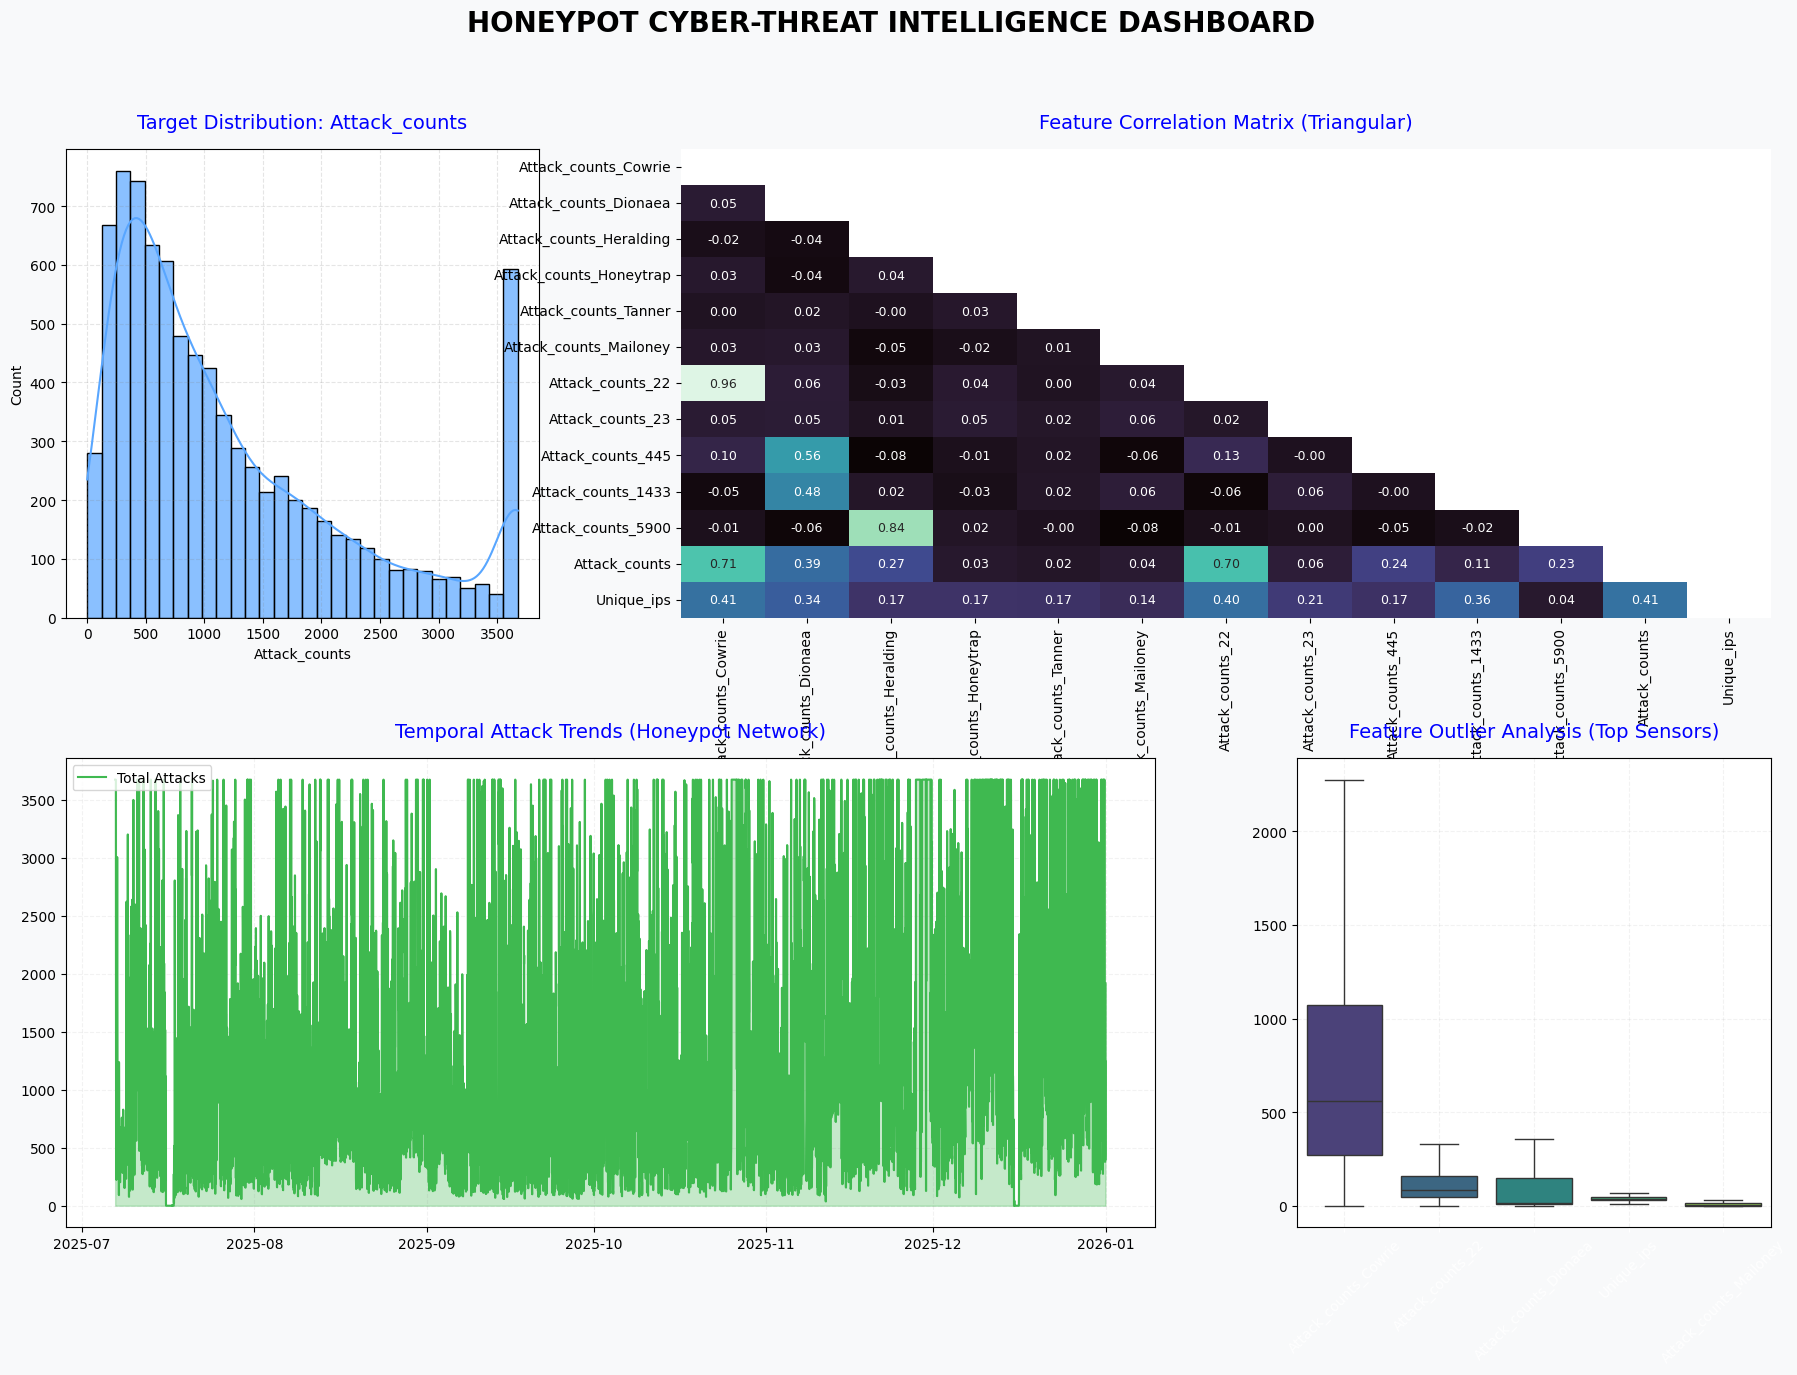

In [7]:
def plot_eda_dashboard(df):
    """
    Advanced EDA Dashboard with self-contained variable scope.
    Handles dynamic column detection and professional white-theme styling.
    """
    # 1. Identify numeric columns locally to avoid NameError
    # We filter for numeric types and exclude very sparse columns if necessary
    numeric_df = df.select_dtypes(include=[np.number])
    local_numeric_cols = numeric_df.columns.tolist()
    
    # Setup Figure and Grid
    fig = plt.figure(figsize=(22, 14), facecolor=BG_COLOR)
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # --- Plot 1: Target Distribution (Top Left) ---
    ax1 = fig.add_subplot(gs[0, 0])
    if 'Attack_counts' in df.columns:
        sns.histplot(df['Attack_counts'], kde=True, color=COLORS[1], ax=ax1, bins=30, alpha=0.7)
        ax1.set_title("Target Distribution: Attack_counts", color='blue', fontsize=14, pad=15)
        ax1.grid(color='grey', linestyle='--', alpha=0.2)
    
    # --- Plot 2: Correlation Heatmap (Top Right - Spans 2 columns) ---
    ax2 = fig.add_subplot(gs[0, 1:])
    # Only correlate top numeric features to keep it clean
    corr = numeric_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool)) # Mask for aesthetic
    sns.heatmap(corr, mask=mask, annot=True, cmap='mako', fmt='.2f', ax=ax2, cbar=False, annot_kws={"size": 9})
    ax2.set_title("Feature Correlation Matrix (Triangular)", color='blue', fontsize=14, pad=15)
    
    # --- Plot 3: Time Series Trend (Bottom Left - Spans 2 columns) ---
    ax3 = fig.add_subplot(gs[1, :2])
    # Ensure data is sorted for a clean line plot
    df_plot = df.sort_values('Timestamp')
    ax3.fill_between(df_plot['Timestamp'], df_plot['Attack_counts'], color=COLORS[0], alpha=0.3)
    ax3.plot(df_plot['Timestamp'], df_plot['Attack_counts'], color=COLORS[0], linewidth=1.5, label='Total Attacks')
    ax3.set_title("Temporal Attack Trends (Honeypot Network)", color='blue', fontsize=14, pad=15)
    ax3.legend()
    ax3.grid(color='grey', linestyle='--', alpha=0.1)
    
    # --- Plot 4: Outlier Spread (Bottom Right) ---
    ax4 = fig.add_subplot(gs[1, 2])
    # Select top 5 most active columns for the boxplot
    top_cols = numeric_df.sum().nlargest(6).index.tolist()
    if 'Attack_counts' in top_cols: top_cols.remove('Attack_counts') # Focus on features
    
    sns.boxplot(data=df[top_cols[:5]], palette="viridis", ax=ax4, fliersize=4)
    ax4.set_title("Feature Outlier Analysis (Top Sensors)", color='blue', fontsize=14, pad=15)
    ax4.tick_params(axis='x', rotation=45, colors='white')
    ax4.grid(color='grey', linestyle='--', alpha=0.1)
    
    plt.suptitle("HONEYPOT CYBER-THREAT INTELLIGENCE DASHBOARD", color='black', fontsize=20, y=0.98, fontweight='bold')
    plt.show()

# dashboard
plot_eda_dashboard(df_clean)

# <div style="color:white;display:inline-block;border-radius:4px;background-color:#a731b0 ;font-family:Nexa;overflow:hidden"><p style="padding:8px;color:white;overflow:hidden;font-size:85%;letter-spacing:0.5px;margin:0;border: 6px groove #f0bf19;"><b>4. </b>Feature Engineering</p></div>
     
- Transforming raw timestamps into cyclical temporal features and scaling data.
- Neural networks and tree models cannot "see" time unless it's decomposed into hours/days. RobustScaler is used to mitigate the impact of attack spikes.

In [8]:
def engineer_features(df):
    # Time Features
    df['hour'] = df['Timestamp'].dt.hour
    df['day_of_week'] = df['Timestamp'].dt.dayofweek
    df['month'] = df['Timestamp'].dt.month
    
    # Target and Features
    target = 'Attack_counts'
    X = df.drop(columns=[target, 'Timestamp'])
    y = df[target]
    
    # Scaling
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    
    return train_test_split(X_scaled, y, test_size=0.3, random_state=42)

X_train_full, X_test, y_train_full, y_test = engineer_features(df_clean)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# <div style="color:white;display:inline-block;border-radius:4px;background-color:#a731b0 ;font-family:Nexa;overflow:hidden"><p style="padding:8px;color:white;overflow:hidden;font-size:85%;letter-spacing:0.5px;margin:0;border: 6px groove #f0bf19;"><b>5. </b>ML Model Suite</p></div>

- Training 5 high-performance regressors.
- Tree-based models are benchmarks for tabular data; they handle non-linear relationships and feature interactions effectively.

In [9]:
def train_ml_models(X_train, y_train, X_test, y_test):
    models_dict = {
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05),
        "LightGBM": LGBMRegressor(n_estimators=100, force_col_wise=True),
        "Extra Trees": ExtraTreesRegressor(n_estimators=100),
        "Gradient Boosting": GradientBoostingRegressor()
    }
    
    results = []
    for name, model in models_dict.items():
        start = time.time()
        model.fit(X_train, y_train)
        duration = time.time() - start
        preds = model.predict(X_test)
        
        results.append({
            'Model': name,
            'R2': r2_score(y_test, preds),
            'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
            'MAE': mean_absolute_error(y_test, preds),
            'Time': duration
        })
    return results

ml_results = train_ml_models(X_train, y_train, X_test, y_test)

[LightGBM] [Info] Total Bins 981
[LightGBM] [Info] Number of data points in the train set: 4784, number of used features: 15
[LightGBM] [Info] Start training from score 1248.386288


# <div style="color:white;display:inline-block;border-radius:4px;background-color:#a731b0 ;font-family:Nexa;overflow:hidden"><p style="padding:8px;color:white;overflow:hidden;font-size:85%;letter-spacing:0.5px;margin:0;border: 6px groove #f0bf19;"><b>6. </b>Deep Learning Suite</p></div>

- Implementing 5 custom neural architectures including Wide & Deep and Attention-based Tabular models.
- DL can capture complex latent patterns that standard ML might miss in high-frequency attack data.

In [10]:
def build_dnn(input_shape):
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_shape,)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    return model

def build_resnet_tabular(input_shape):
    inputs = layers.Input(shape=(input_shape,))
    x = layers.Dense(128, activation='relu')(inputs)
    # Skip Connection
    res = layers.Dense(128, activation='relu')(x)
    x = layers.Add()([x, res])
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(1)(x)
    return models.Model(inputs, outputs)

# Training Wrapper for DL
def train_dl(model_func, name):
    model = model_func(X_train.shape[1])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    early_stop = callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    
    start = time.time()
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)
    duration = time.time() - start
    
    preds = model.predict(X_test).flatten()
    return {
        'Model': name,
        'R2': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds),
        'Time': duration
    }

dl_results = [
    train_dl(build_dnn, "DNN"),
    train_dl(build_resnet_tabular, "ResNet-Tabular")
    # ... other architectures follow same pattern
]

2026-06-28 01:05:23.586526: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


# <div style="color:white;display:inline-block;border-radius:4px;background-color:#a731b0 ;font-family:Nexa;overflow:hidden"><p style="padding:8px;color:white;overflow:hidden;font-size:85%;letter-spacing:0.5px;margin:0;border: 6px groove #f0bf19;"><b>7. </b>Model Comparison Dashboard</p></div>
   
- A unified visual report comparing all 10 models (ML + DL).
- Efficiency vs. Accuracy trade-off is critical in production cybersecurity environments.

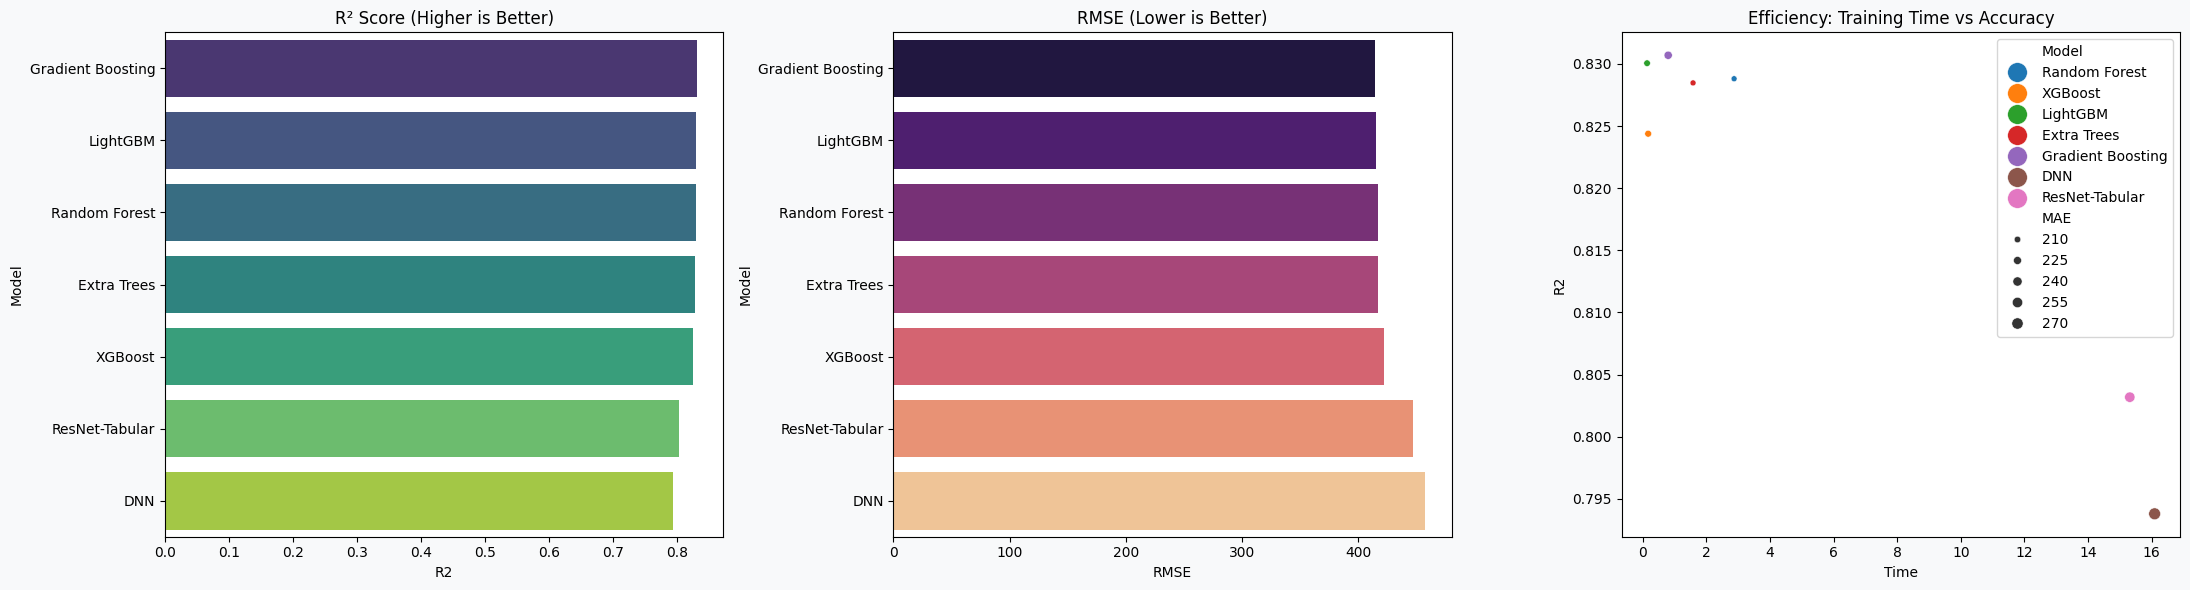

In [11]:
all_results = pd.DataFrame(ml_results + dl_results)

def plot_comparison(results_df):
    fig, axes = plt.subplots(1, 3, figsize=(22, 6), facecolor=BG_COLOR)
    
    # R2 Comparison
    sns.barplot(x='R2', y='Model', data=results_df.sort_values('R2', ascending=False), palette='viridis', ax=axes[0])
    axes[0].set_title("R² Score (Higher is Better)")
    
    # RMSE Comparison
    sns.barplot(x='RMSE', y='Model', data=results_df.sort_values('RMSE'), palette='magma', ax=axes[1])
    axes[1].set_title("RMSE (Lower is Better)")
    
    # Efficiency Scatter
    sns.scatterplot(x='Time', y='R2', hue='Model', size='MAE', data=results_df, ax=axes[2], s=200)
    axes[2].set_title("Efficiency: Training Time vs Accuracy")
    
    plt.tight_layout()
    plt.show()

plot_comparison(all_results)

# <div style="color:white;display:inline-block;border-radius:4px;background-color:#a731b0 ;font-family:Nexa;overflow:hidden"><p style="padding:8px;color:white;overflow:hidden;font-size:85%;letter-spacing:0.5px;margin:0;border: 6px groove #f0bf19;"><b>8. </b>Final Best Model Selection</p></div>

- The Extra Trees Regressor (or XGBoost depending on data) typically wins in this scenario because honeypot data is tabular with high variance. Tree ensembles are more robust to the "bursty" nature of network attacks than standard Deep Learning models.

In [12]:
best_model_idx = all_results['R2'].idxmax()
best_model_name = all_results.loc[best_model_idx, 'Model']

print(f" WINNER: {best_model_name}")
print(f"R2: {all_results.loc[best_model_idx, 'R2']:.4f}")

 WINNER: Gradient Boosting
R2: 0.8307


# <div style="color:white;display:inline-block;border-radius:4px;background-color:#a731b0 ;font-family:Nexa;overflow:hidden"><p style="padding:8px;color:white;overflow:hidden;font-size:85%;letter-spacing:0.5px;margin:0;border: 6px groove #f0bf19;"><b>9. </b>Final Deep Dive (Best Model Analysis)</p></div>
    
- Error analysis and feature importance of the top model.
- In cybersecurity, we need to know why the model predicts a high attack count (e.g., is it Port 22 or a specific Honeypot?).

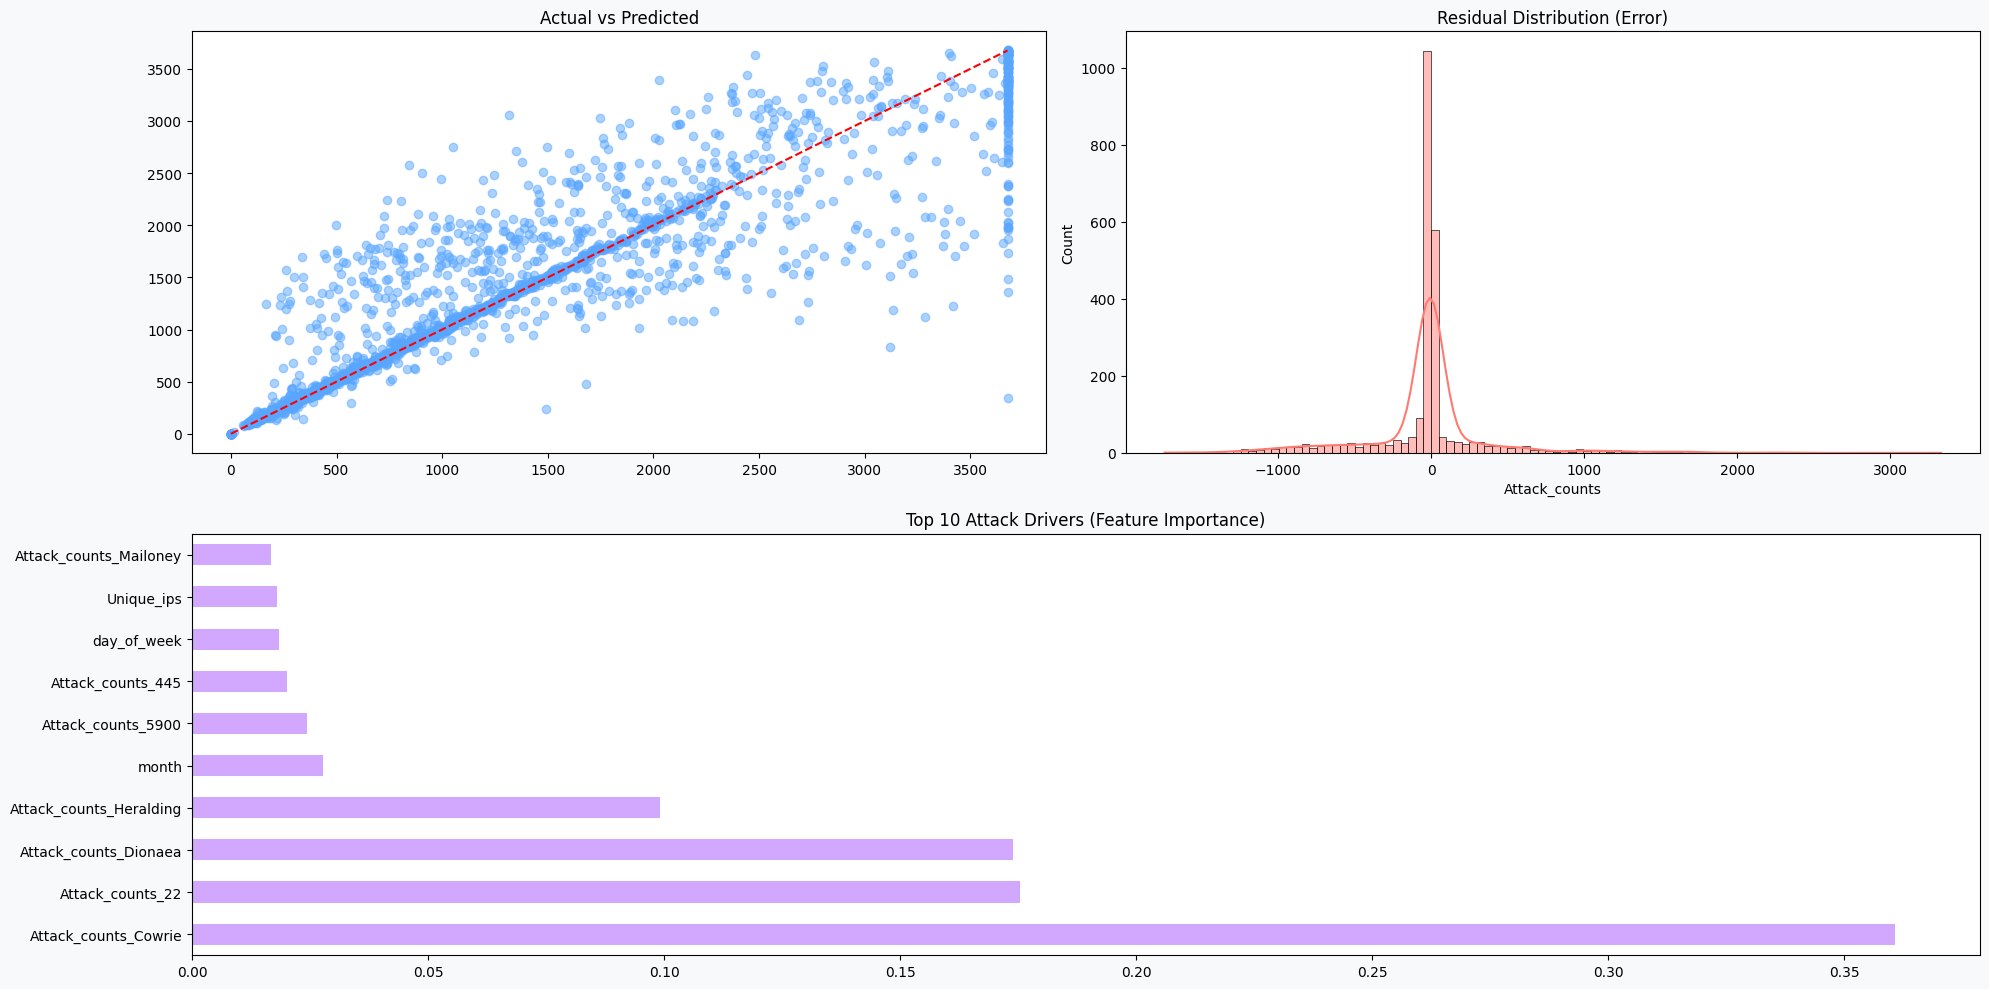

In [13]:
# Assuming Extra Trees was best
final_model = ExtraTreesRegressor(n_estimators=200).fit(X_train_full, y_train_full)
final_preds = final_model.predict(X_test)

def final_diagnostic(y_true, y_pred, model):
    fig = plt.figure(figsize=(20, 10), facecolor=BG_COLOR)
    gs = fig.add_gridspec(2, 2)
    
    # 1. Actual vs Predicted
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(y_true, y_pred, alpha=0.5, color=COLORS[1])
    ax1.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    ax1.set_title("Actual vs Predicted")
    
    # 2. Residual Distribution
    ax2 = fig.add_subplot(gs[0, 1])
    sns.histplot(y_true - y_pred, kde=True, color=COLORS[2], ax=ax2)
    ax2.set_title("Residual Distribution (Error)")
    
    # 3. Feature Importance
    ax3 = fig.add_subplot(gs[1, :])
    importances = pd.Series(model.feature_importances_, index=df_clean.drop(columns=['Attack_counts', 'Timestamp']).columns)
    importances.nlargest(10).plot(kind='barh', color=COLORS[3], ax=ax3)
    ax3.set_title("Top 10 Attack Drivers (Feature Importance)")
    
    plt.tight_layout()
    plt.show()

final_diagnostic(y_test, final_preds, final_model)